In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from datetime import datetime

In [ ]:
df=pd.read_csv(r"D:\Python\ML\Projects\Linear\NY Taxi\nyc_taxi_trip_duration.csv")
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  str    
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  str    
 3   dropoff_datetime    729322 non-null  str    
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  str    
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 61.2 MB


In [9]:
df=df.drop('id',axis=1)

In [10]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [11]:
df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  dayfirst=True)
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], dayfirst=True)

In [12]:
df['hour']=df['pickup_datetime'].dt.hour
df['day_of_week']=df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year']=df['pickup_datetime'].dt.year
df['is_rush']=df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_weekend']=(df['day_of_week']>=5).astype(int)
df['is_night']=(df['hour']<6).astype(int)

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km']=haversine(df["pickup_latitude"],  df["pickup_longitude"],df["dropoff_latitude"], df["dropoff_longitude"])

In [14]:
target='trip_duration'
features=['vendor_id', 'passenger_count', 'hour', 'day_of_week', 'pickup_month', 'pickup_year', 'is_rush', 'is_weekend','is_night', 'distance_km']


In [15]:
df = df.dropna(subset=[target, "distance_km"])
df = df[df[target]        > 0]       # remove zero/negative durations
df = df[df[target]        < 10_000]  # remove extreme outliers (seconds)
df = df[df["distance_km"] > 0]       # remove zero-distance trips
df = df[df["distance_km"] < 100]     # remove unrealistic distances
df = df[df["passenger_count"].between(1, 6)]

In [16]:
X=df[features]
y=df[target]
X.head()

,vendor_id,passenger_count,hour,day_of_week,pickup_month,pickup_year,is_rush,is_weekend,is_night,distance_km
0,2,1,16,0,2,2016,0,0,0,1.199072
1,1,2,23,4,3,2016,0,0,0,4.129111
2,2,2,17,6,2,2016,1,1,0,7.250752
3,2,6,9,1,1,2016,1,0,0,2.361097
4,1,1,6,2,2,2016,0,0,0,4.328533


In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((580281, 10), (145071, 10))

In [18]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [19]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
from sklearn.model_selection import cross_val_score
cv=cross_val_score(model,X_train,y_train,cv=5)
np.mean(cv)

np.float64(0.6087927884548033)

In [21]:
y_pred=model.predict(X_test)

In [22]:
mse=mean_squared_error(y_test,y_pred)
R2=r2_score(y_test,y_pred)
print(f"nMSE: {mse}\nR2_SCORE: {R2}")

nMSE: 164403.4144752845
R2_SCORE: 0.613305009420596


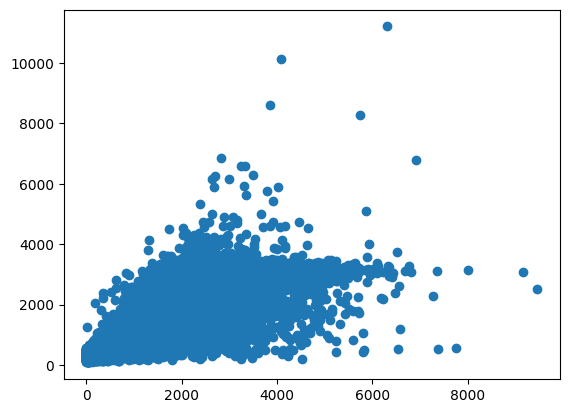

In [23]:
plt.scatter(y_test,y_pred)

In [24]:
from sklearn.linear_model import Ridge,Lasso
ridge=Ridge(alpha=1)
ridge.fit(X_train,y_train)
r_pred=ridge.predict(X_test)

In [25]:
mse=mean_squared_error(y_test,r_pred)
R2=r2_score(y_test,r_pred)
print(f"nMSE: {mse}\nR2_SCORE: {R2}")

nMSE: 164403.41403482622
R2_SCORE: 0.6133050104566025


In [26]:
lasso=Lasso(alpha=0.01)
lasso.fit(X_train,y_train)
l_pred=lasso.predict(X_test)

In [27]:
mse=mean_squared_error(y_test,l_pred)
R2=r2_score(y_test,l_pred)
print(f"nMSE: {mse}\nR2_SCORE: {R2}")

nMSE: 164403.36328779926
R2_SCORE: 0.6133051298192154


In [29]:
elastic=ElasticNet(alpha=0.1,l1_ratio=0.5,random_state=42)
elastic.fit(X_train,y_train)
e_pred=elastic.predict(X_test)
r2score=r2_score(y_test,e_pred)
r2score

0.6116918085735994